In [3]:
 # importing required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Loading the dataframe
data = pd.read_csv("Superstore.csv",encoding='latin-1')

In [7]:
# Displaying random records in a dataframe.
data.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9945,9946,CA-2014-111157,3/2/2014,3/6/2014,Standard Class,NH-18610,Nicole Hansen,Corporate,United States,Philadelphia,...,19120,East,OFF-PA-10000327,Office Supplies,Paper,Xerox 1971,3.424,1,0.2,1.0700
2367,2368,CA-2017-123659,2/10/2017,2/13/2017,First Class,MN-17935,Michael Nguyen,Consumer,United States,Clinton,...,20735,East,OFF-PA-10002464,Office Supplies,Paper,HP Office Recycled Paper (20Lb. and 87 Bright),23.120,4,0.0,11.3288
766,767,CA-2014-162775,1/13/2014,1/15/2014,Second Class,CS-12250,Chris Selesnick,Corporate,United States,Bossier City,...,71111,South,OFF-BI-10004187,Office Supplies,Binders,3-ring staple pack,5.640,3,0.0,2.7072
4154,4155,CA-2016-139689,12/29/2016,1/3/2017,Standard Class,MP-17965,Michael Paige,Corporate,United States,Bristol,...,37620,South,OFF-BI-10004781,Office Supplies,Binders,GBC Wire Binding Strips,38.088,4,0.7,-27.9312
415,416,CA-2017-142636,11/3/2017,11/7/2017,Standard Class,KC-16675,Kimberly Carter,Corporate,United States,Seattle,...,98105,West,FUR-CH-10001891,Furniture,Chairs,Global Deluxe Office Fabric Chairs,307.136,4,0.2,26.8744


In [10]:
# shape of the dataframe
data.shape

(9994, 21)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [12]:
# Descriptive statistics for numerical coulumns.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [13]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9994.0,NaN,NaN,NaN,4997.5,2885.163629,1.0,2499.25,4997.5,7495.75,9994.0
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,1237,9/5/2016,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9994,1334,12/16/2015,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
data["Order Date"] = pd.to_datetime(data["Order Date"])

In [19]:
data["Ship Date"] = pd.to_datetime(data["Ship Date"])

In [20]:
data["order_month"] = pd.to_datetime(data["Order Date"]).dt.month_name()

In [21]:
data["order_year"] = pd.to_datetime(data["Order Date"]).dt.year

In [23]:
data["Ship_month"] = pd.to_datetime(data["Ship Date"]).dt.month_name()

In [25]:
data["Ship_year"] = pd.to_datetime(data["Ship Date"]).dt.month_name()

In [28]:
data["Ship_year"] = pd.to_datetime(data["Ship Date"]).dt.year

In [29]:
data.sample(n=1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,order_month,order_year,Ship_month,Ship_year
5673,5674,CA-2017-127922,2017-10-27,2017-11-03,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Dallas,...,Paper,Xerox 1972,8.448,2,0.2,2.64,October,2017,November,2017


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# Missing Value Treatment

In [31]:
# Exploratoty Data Analysis

In [32]:
# Calculating Monthly Sales.
monthly_sales = data.groupby("order_month")["Sales"].sum().reset_index().sort_values(by='Sales',ascending=False)

In [33]:
monthly_sales

,order_month,Sales
9,November,352461.0710
2,December,325293.5035
11,September,307649.9457
7,March,205005.4888
10,October,200322.9847
1,August,159044.0630
8,May,155028.8117
6,June,152718.6793
5,July,147238.0970
0,April,137762.1286


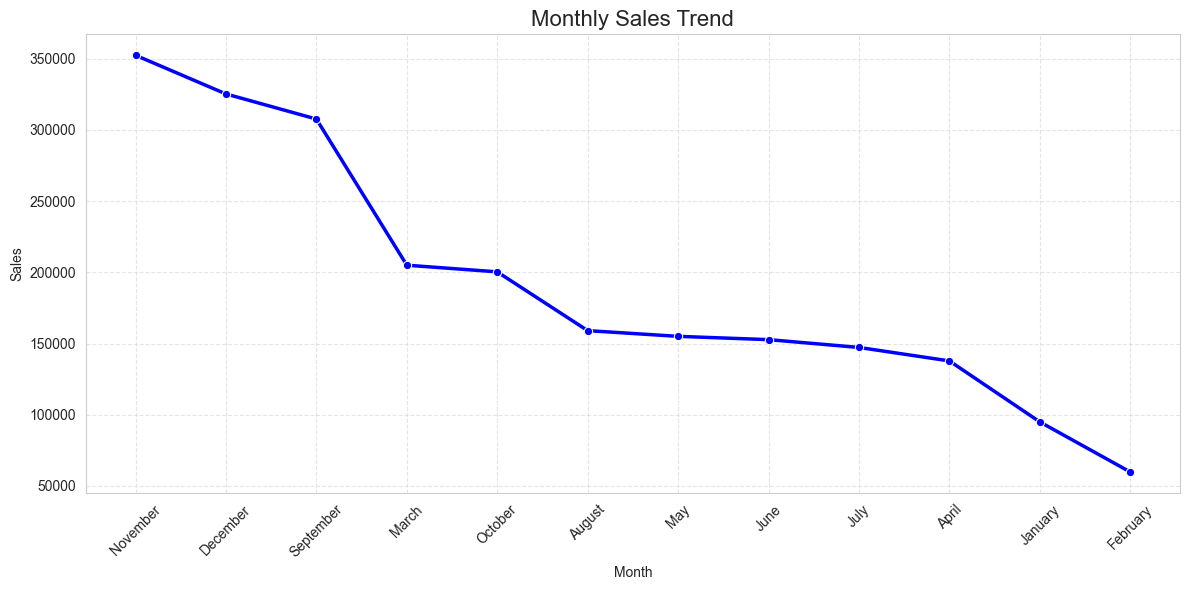

In [38]:

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

sns.lineplot(
    monthly_sales,
    x="order_month",
    y="Sales",
    marker="o",
    linewidth=2.5,
    color="blue"
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [39]:
# Sales on the basis of Category
category_sales = data.groupby('Category')["Sales"].sum()

In [41]:
category_sales

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

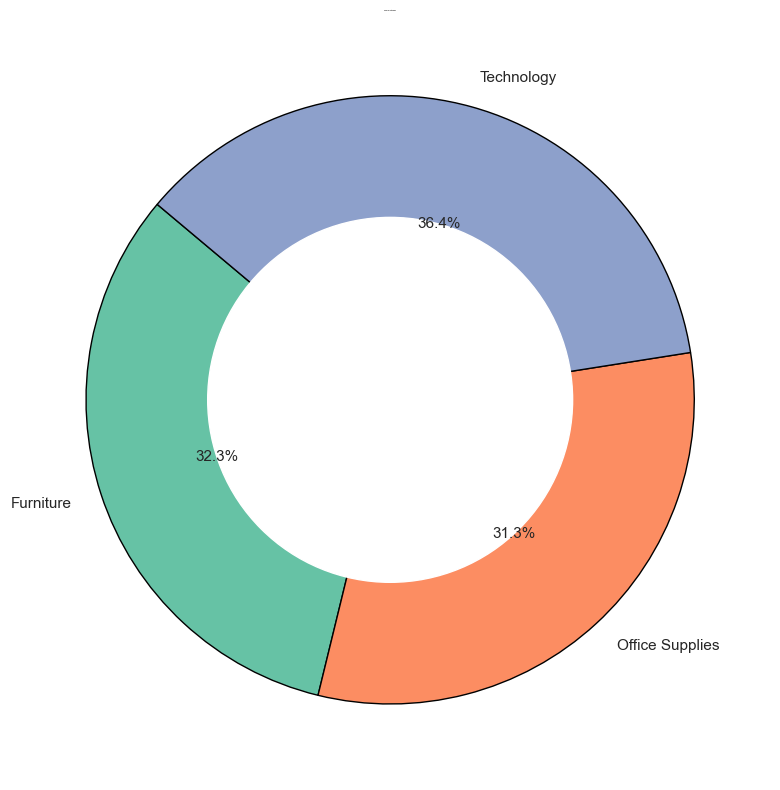

In [55]:

plt.figure(figsize=(8,8))
sns.set_style("white")

colors = sns.color_palette("Set2")

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1},
    textprops={'fontsize': 11}
)

plt.title("Sales by Category", fontsize=0.0, fontweight='bold')

# donut style (modern look)
centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()



In [57]:
# sales per Sub-Category
Sub_category_sales = data.groupby('Sub-Category')["Sales"].sum().reset_index()

In [60]:
Sub_category_sales

,Sub-Category,Sales
0,Accessories,167380.3180
1,Appliances,107532.1610
2,Art,27118.7920
3,Binders,203412.7330
4,Bookcases,114879.9963
5,Chairs,328449.1030
6,Copiers,149528.0300
7,Envelopes,16476.4020
8,Fasteners,3024.2800
9,Furnishings,91705.1640


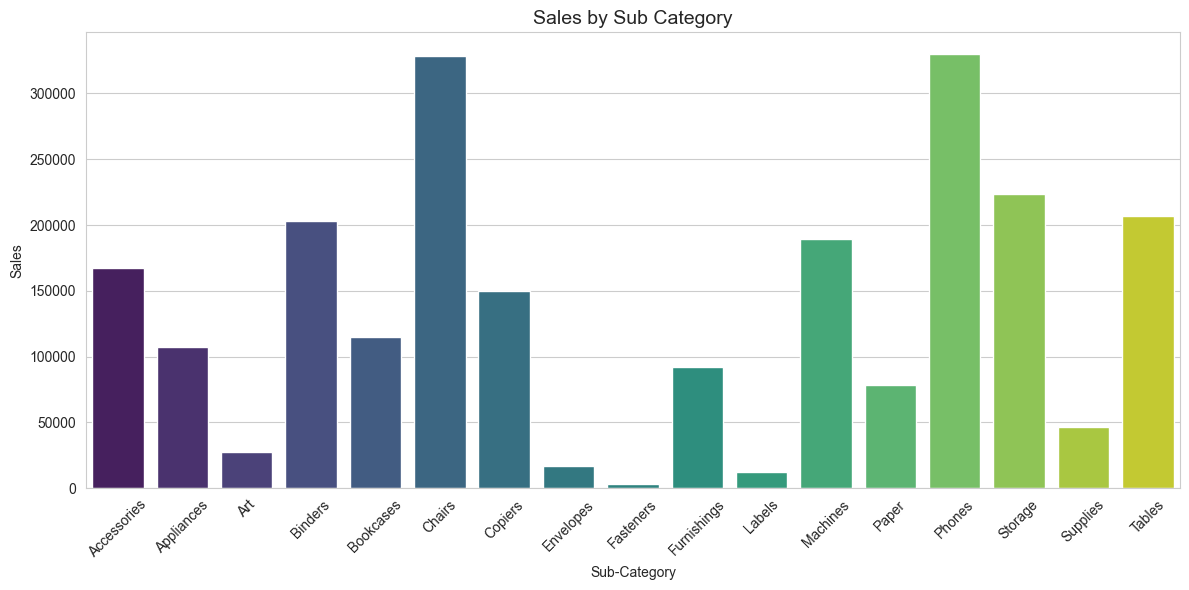

In [62]:

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

sns.barplot(
    Sub_category_sales,
    x='Sub-Category',
    y='Sales',
    palette='viridis'
)

plt.title("Sales by Sub Category", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Profit Analysis

In [63]:
# Profit's earned each month.
monthly_profit = data.groupby("order_month")["Profit"].sum().reset_index()

In [64]:
monthly_profit


,order_month,Profit
0,April,11587.4363
1,August,21776.9384
2,December,43369.1919
3,February,10294.6107
4,January,9134.4461
5,July,13832.6648
6,June,21285.7954
7,March,28594.6872
8,May,22411.3078
9,November,35468.4265


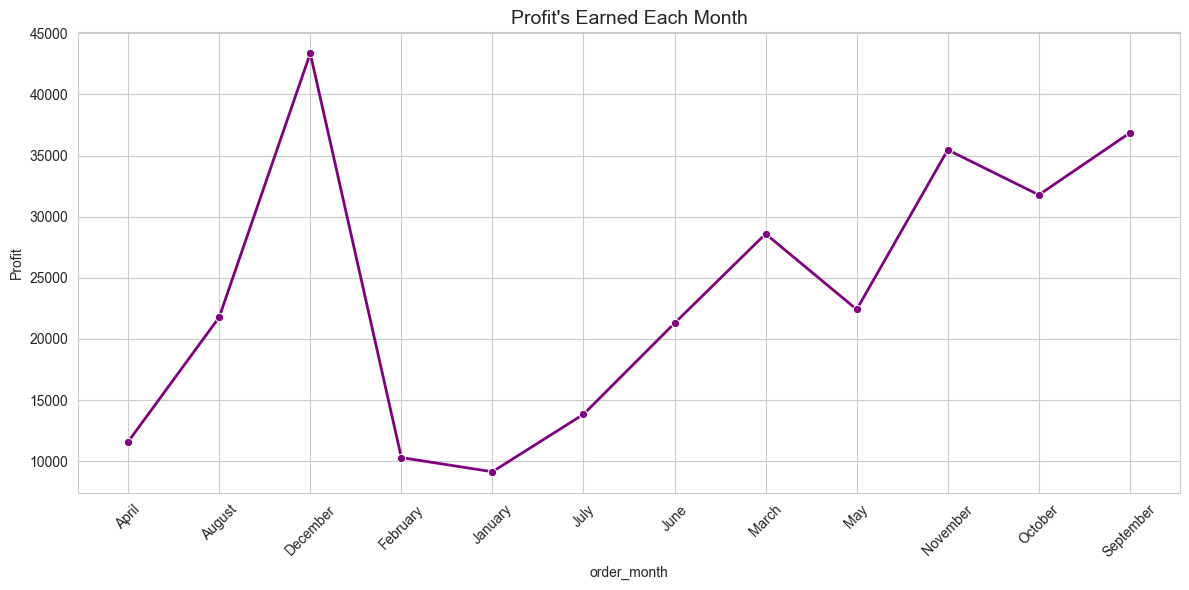

In [66]:

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

sns.lineplot(
    monthly_profit,
    x="order_month",
    y="Profit",
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title("Profit's Earned Each Month", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [67]:
# profit's earned per annum.
annual_profit = data.groupby("order_year")["Profit"].sum().reset_index()

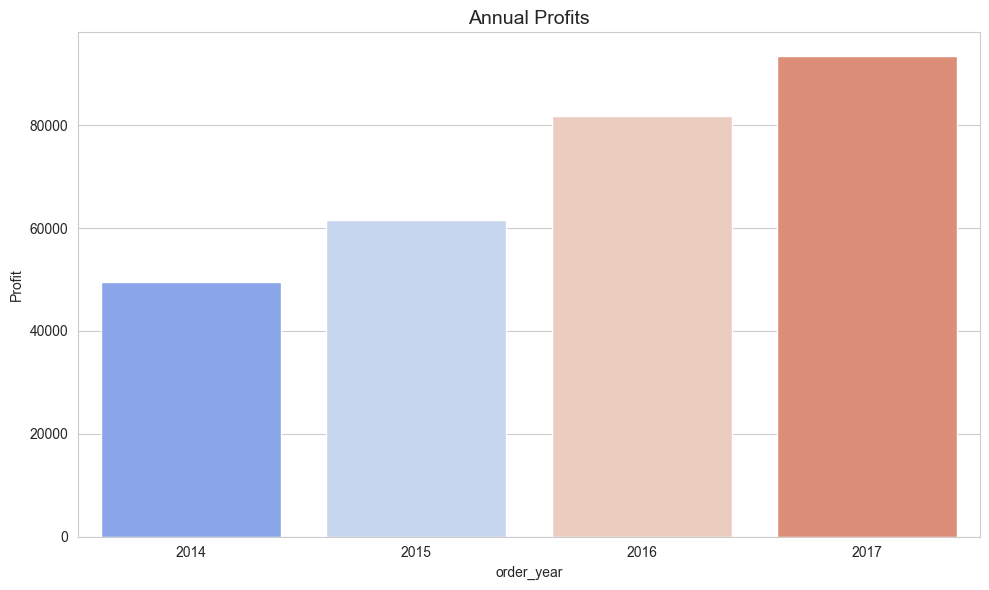

In [69]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.barplot(
    annual_profit,
    x="order_year",
    y="Profit",
    palette="coolwarm"
)

plt.title("Annual Profits", fontsize=14)

plt.tight_layout()
plt.show()


In [70]:
#Profit's earned by each category.
category_profits = data.groupby("Category")["Profit"].sum()

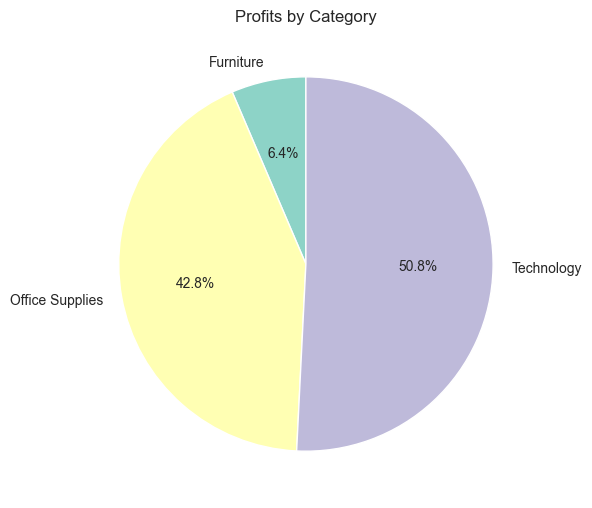

In [74]:
plt.figure(figsize=(6,6))
sns.set_style("white")

plt.title("Profits by Category")

colors = sns.color_palette("Set3")

plt.pie(
    category_profits,
    labels=category_profits.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.tight_layout()
plt.show()


In [75]:
# Profit's earned by each sub category
sub_profit = data.groupby("Sub-Category")["Profit"].sum().reset_index()

In [76]:
sub_profit


,Sub-Category,Profit
0,Accessories,41936.6357
1,Appliances,18138.0054
2,Art,6527.7870
3,Binders,30221.7633
4,Bookcases,-3472.5560
5,Chairs,26590.1663
6,Copiers,55617.8249
7,Envelopes,6964.1767
8,Fasteners,949.5182
9,Furnishings,13059.1436


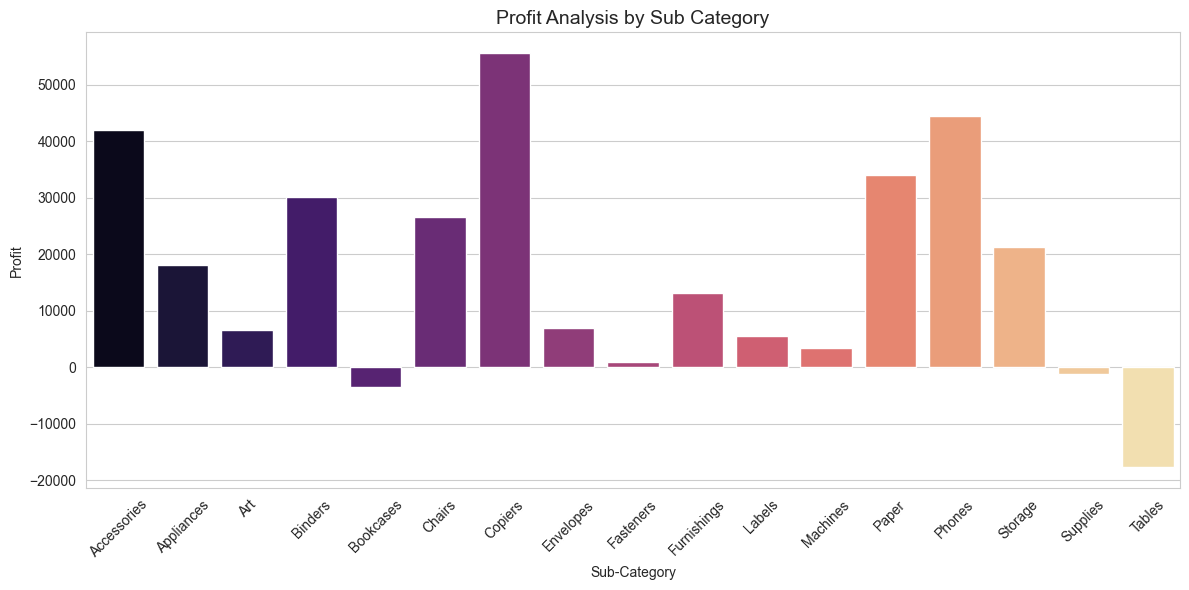

In [78]:
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

sns.barplot(
    sub_profit,
    x="Sub-Category",
    y="Profit",
    palette="magma"
)

plt.title("Profit Analysis by Sub Category", fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [79]:
segment = data.groupby("Segment")[["Sales","Profit"]].sum()

In [80]:
segment

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [9]:
# Shape of the DataFrame
data.shape

(9994, 21)

Text(0, 0.5, 'Sales,Profit')

<Figure size 1200x600 with 0 Axes>

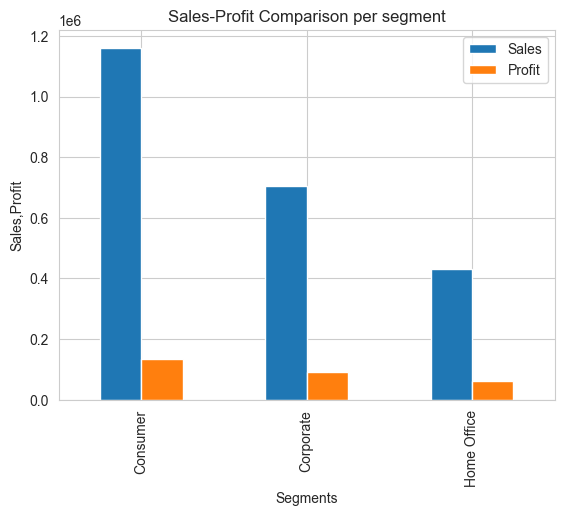

In [83]:
plt.figure(figsize=(12, 6))
segment.plot(kind='bar')
plt.title("Sales-Profit Comparison per segment")
plt.xlabel("Segments")
plt.ylabel("Sales,Profit")



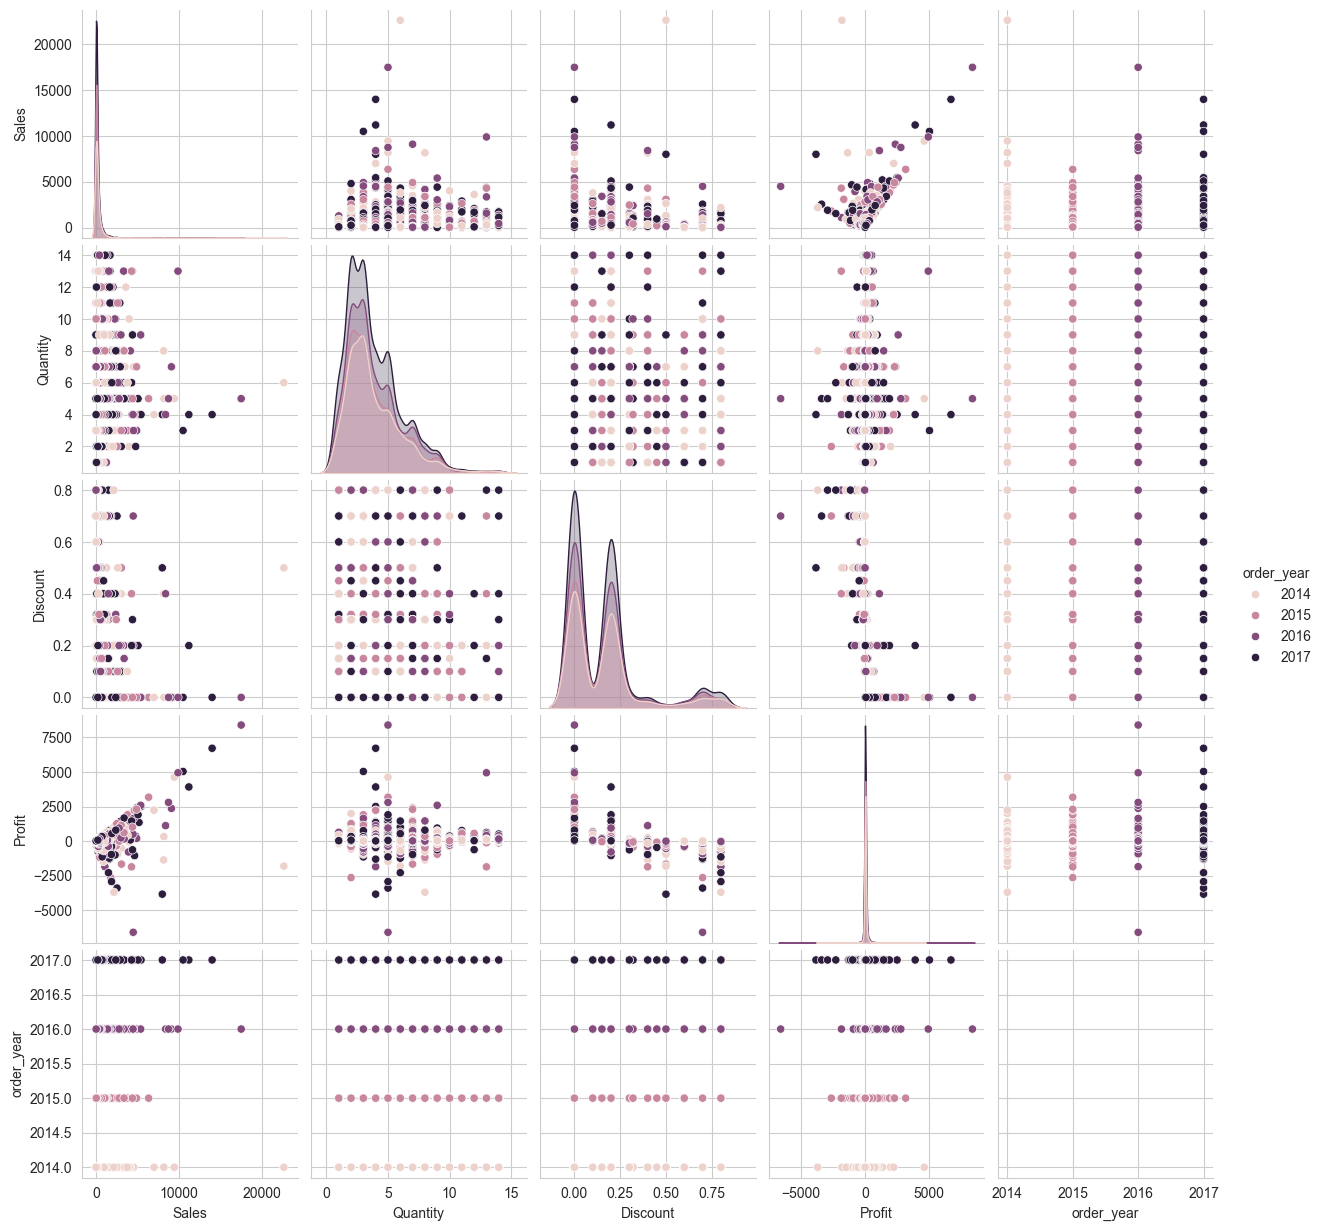

In [14]:
data['order_year'] = pd.to_datetime(data['Order Date']).dt.year

sns.pairplot(
    data,
    vars=['Sales', 'Quantity', 'Discount', 'Profit', 'order_year'],
    hue='order_year'
)

plt.show()


In [15]:
# Shape of the DataFrame
data.shape

(9994, 22)

In [18]:
# create Ship_year column first
data['Ship_year'] = pd.to_datetime(data['Ship Date']).dt.year

# now your same code
Num1 = data[['Row ID', 'Postal Code','Sales', 'Quantity', 'Discount', 'Profit', 'Ship_year']]


In [20]:
# create missing columns
data['order_month'] = pd.to_datetime(data['Order Date']).dt.to_period('M').astype(str)
data['Ship_month'] = pd.to_datetime(data['Ship Date']).dt.to_period('M').astype(str)

# now your same code
Cat1 = data[['Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'order_month', 'Ship_month',
       'Product Name']]


In [21]:
columns = data[['Row ID', 'Sales', 'Quantity', 'Discount', 'Profit']]

In [22]:
columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Row ID    9994 non-null   int64  
 1   Sales     9994 non-null   float64
 2   Quantity  9994 non-null   int64  
 3   Discount  9994 non-null   float64
 4   Profit    9994 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 390.5 KB


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [24]:
# Create a correlation matrix
corr_matrix = Num1.corr()

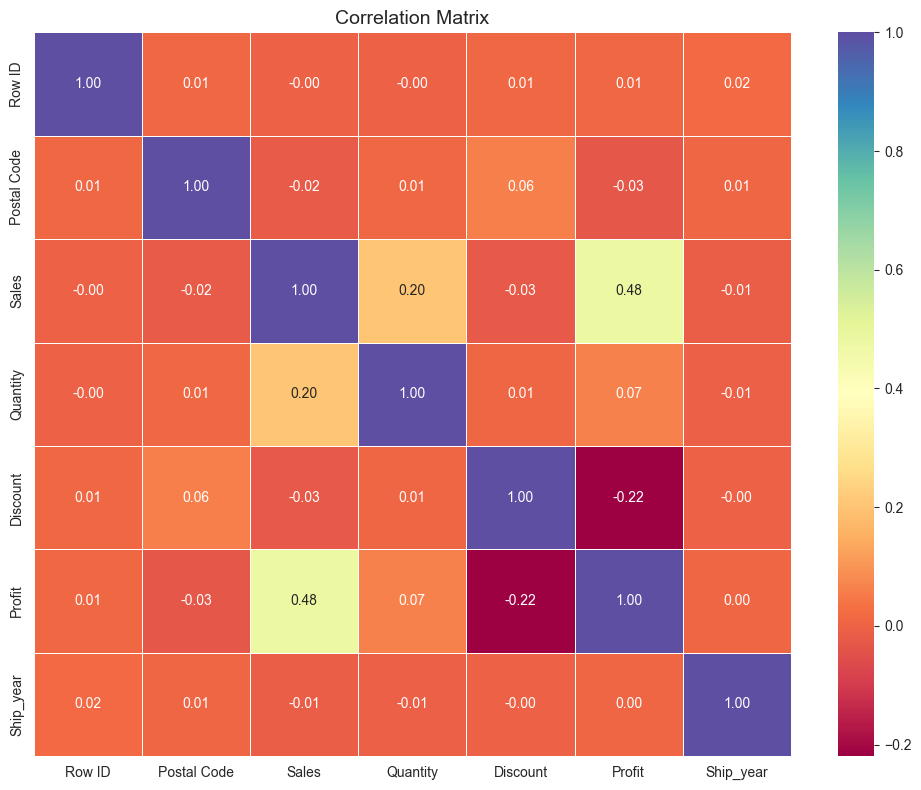

In [28]:
# # Plot the correlation matrix using a heatmap
# plt.figure(figsize=(8, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.figure(figsize=(10,8))
sns.set_style("white")

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Spectral",
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar=True
)

plt.title("Correlation Matrix", fontsize=14)

plt.tight_layout()
plt.show()


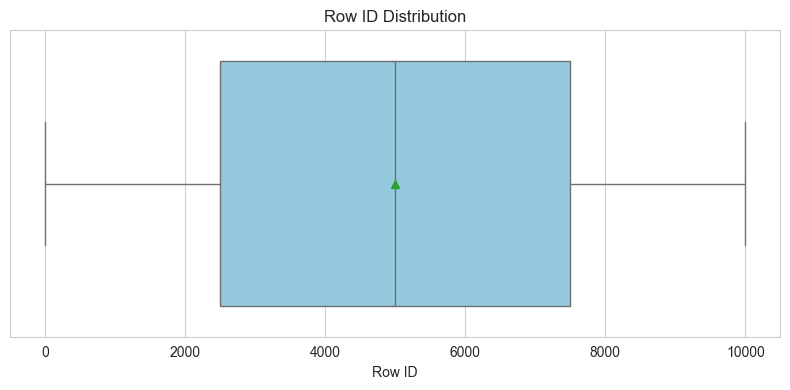

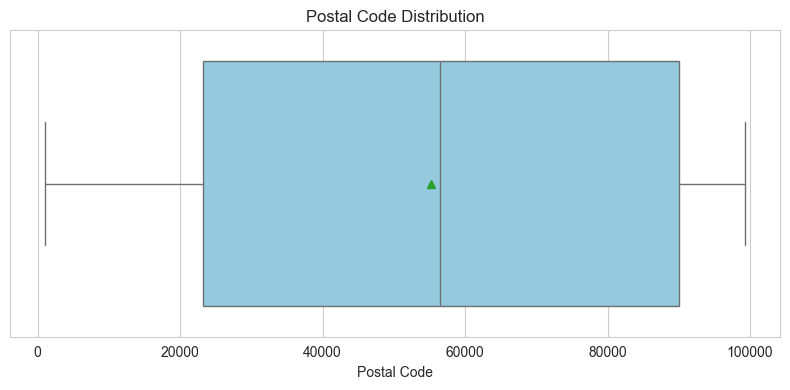

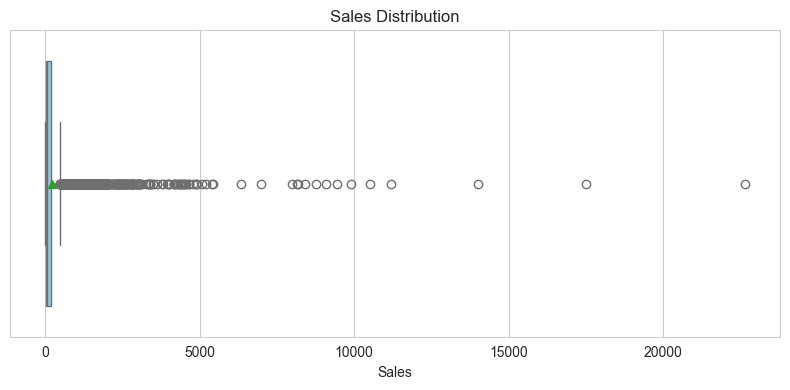

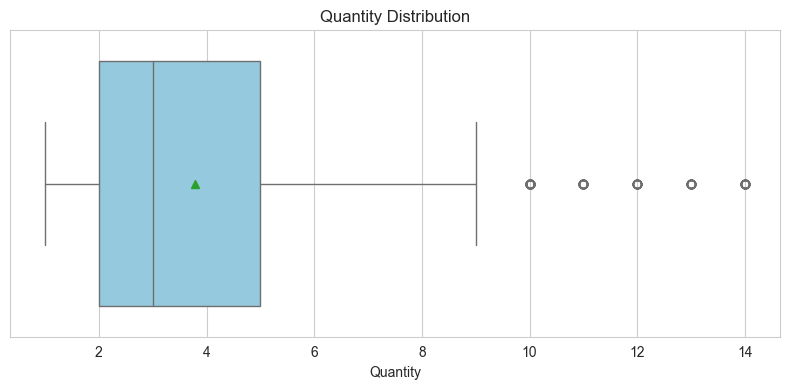

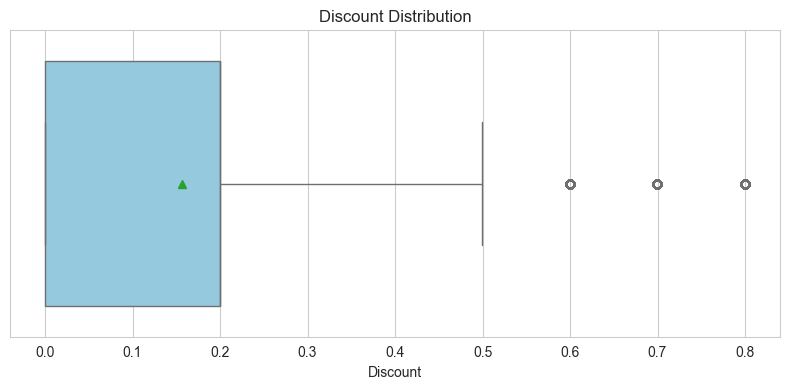

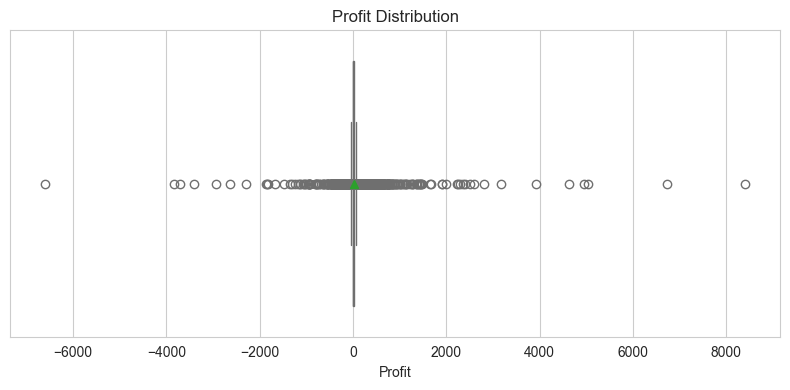

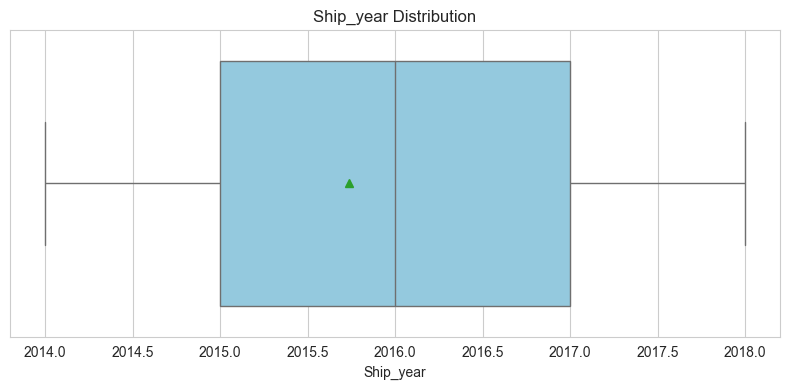

In [30]:
sns.set_style("whitegrid")

for col in Num1.columns:
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        x=Num1[col],
        showmeans=True,
        color="skyblue"
    )
    
    plt.title(f"{col} Distribution", fontsize=12)
    
    plt.tight_layout()
    plt.show()


In [31]:
# Using exponential method to reduce outliers
exp = data[[ 'Sales', 'Quantity', 'Discount', 'Profit']]

In [32]:
np.exp(exp["Sales"])

0       5.858447e+113
1                 inf
2        2.235555e+06
3                 inf
4        5.179633e+09
            ...      
9989     9.227139e+10
9990     8.664042e+39
9991    1.986689e+112
9992     7.163358e+12
9993    4.009094e+105
Name: Sales, Length: 9994, dtype: float64

In [33]:
# Using for-loop for reducing treatment
for i in exp.columns:
    exp[i] = np.exp(exp[i])

In [35]:
exp

,Sales,Quantity,Discount,Profit
0,5.858447e+113,7.389056,1.000000,1.595310e+18
1,inf,20.085537,1.000000,2.308080e+95
2,2.235555e+06,7.389056,1.000000,9.642976e+02
3,inf,148.413159,1.568312,4.484875e-167
4,5.179633e+09,7.389056,1.221403,1.238393e+01
...,...,...,...,...
9989,9.227139e+10,20.085537,1.221403,6.050948e+01
9990,8.664042e+39,7.389056,1.000000,6.157614e+06
9991,1.986689e+112,7.389056,1.221403,2.644598e+08
9992,7.163358e+12,54.598150,1.000000,6.092598e+05


In [36]:
# Replacing the values of Num1 dataframe with exponential values.
Num1[[ 'Sales', 'Quantity', 'Discount', 'Profit']] = exp[[ 'Sales', 'Quantity', 'Discount', 'Profit']]

In [37]:
Num1

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Ship_year
0,1,42420,5.858447e+113,7.389056,1.000000,1.595310e+18,2016
1,2,42420,inf,20.085537,1.000000,2.308080e+95,2016
2,3,90036,2.235555e+06,7.389056,1.000000,9.642976e+02,2016
3,4,33311,inf,148.413159,1.568312,4.484875e-167,2015
4,5,33311,5.179633e+09,7.389056,1.221403,1.238393e+01,2015
...,...,...,...,...,...,...,...
9989,9990,33180,9.227139e+10,20.085537,1.221403,6.050948e+01,2014
9990,9991,92627,8.664042e+39,7.389056,1.000000,6.157614e+06,2017
9991,9992,92627,1.986689e+112,7.389056,1.221403,2.644598e+08,2017
9992,9993,92627,7.163358e+12,54.598150,1.000000,6.092598e+05,2017
